<a href="https://colab.research.google.com/github/Parimal1004/MyProjects/blob/main/ML_Customer_Segmentation_using_Clustering_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***1) Title : Customer Segmentation using Clustering Techniques***

This project applies multiple clustering algorithms to segment customers based on their age, income, and spending behavior. The goal is to identify distinct customer groups for better decision-making.

# ***2) Importing Required Libraries***

The necessary libraries for data manipulation, visualization, and clustering are imported.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

## ***3) Loading the Dataset***

The dataset is loaded and initial rows are displayed to understand its structure.

In [ ]:
customer_data = pd.read_excel("/content/AIDS_Segmentation_Dataset (1).xlsx")
customer_data.head()

,Name,Roll Number,Age,Gender,Monthly Allowance (₹),Avg Monthly Spending (₹),Savings per Month (₹),Savings (%),Spending Score (1-100),Outings per Week,Online Shopping (times/month),Preferred Spending Category,Avg Spend per Outing (₹),Social Media (hrs/day),Brand Preference,Impulse Buying (1-10),Discount Sensitivity (1-10)
0,ALLAMAHIMARAO,1601-24-771-001,19,Female,13627,7664,5963,43.8,59,3,5,Clothes,430,2.6,Mid-range,6,5
1,BALIVADAHARSHITHA,1601-24-771-002,18,Female,13504,5188,8316,61.6,27,2,1,Gadgets,202,2.2,Budget,1,9
2,BHUKYAPOOJA,1601-24-771-003,19,Female,20575,16600,3975,19.3,89,5,10,Gadgets,714,6.1,Premium,8,3
3,CHAGIL,1601-24-771-004,18,Male,11743,5023,6720,57.2,29,1,2,Gadgets,151,1.5,Budget,1,8
4,CHIDRAPUSAIVAISHNAVIDEVI,1601-24-771-005,19,Female,8581,5615,2966,34.6,48,1,1,Food,138,1.8,Budget,4,8


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# ***4) Data Cleaning***

Missing values are checked and removed to ensure clean and reliable data for analysis.

In [ ]:
print("Dataset shape  cleaning:", customer_data.shape)
print(customer_data.isnull().sum())

customer_data = customer_data.dropna()
print("Dataset shape after cleaning:", customer_data.shape)

Dataset shape  cleaning: (78, 17)
Name                             0
Roll Number                      0
Age                              0
Gender                           0
Monthly Allowance (₹)            0
Avg Monthly Spending (₹)         0
Savings per Month (₹)            0
Savings (%)                      0
Spending Score (1-100)           0
Outings per Week                 0
Online Shopping (times/month)    0
Preferred Spending Category      0
Avg Spend per Outing (₹)         0
Social Media (hrs/day)           0
Brand Preference                 0
Impulse Buying (1-10)            0
Discount Sensitivity (1-10)      0
dtype: int64
Dataset shape after cleaning: (78, 17)


## ***5) Feature Selection***

Relevant features such as Age, Monthly Allowance, and Spending Score are selected for clustering.

In [ ]:
features = customer_data[['Age', 'Monthly Allowance (₹)', 'Spending Score (1-100)']]

## ***6) Feature Scaling***

Data is standardized using StandardScaler to bring all features to the same scale.

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

## ***7) Dimensionality Reduction using PCA***

Principal Component Analysis (PCA) is applied to reduce the data into 2 dimensions for visualization.

In [ ]:
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

pca_df = pd.DataFrame(pca_features, columns=['PC1', 'PC2'])

## ***8) Finding Optimal Clusters using Elbow Method***

The Elbow Method helps determine the optimal number of clusters for K-Means.
The elbow point is observed at K = 4, where the rate of decrease sharply changes.
Hence, we select 4 clusters as the optimal number of customer groups.

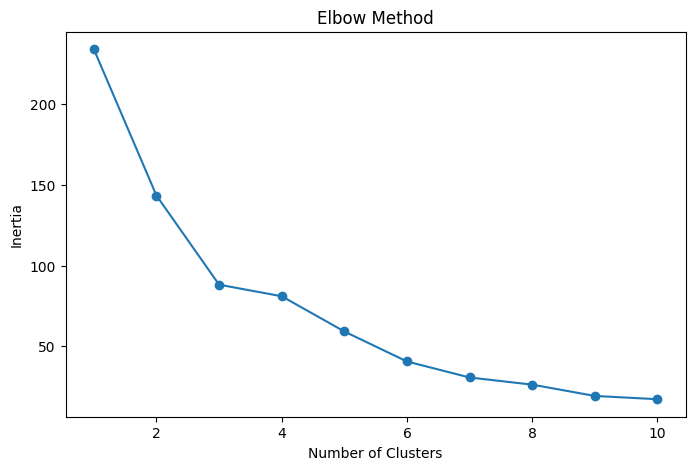

In [ ]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

## ***9) K-Means Clustering***

K-Means is applied with the optimal number of clusters to segment customers.

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

customer_data['KMeans_Cluster'] = clusters
pca_df['Cluster'] = clusters
cluster_names = {
    0: "Budget Customers",
    1: "Premium Customers",
    2: "Impulse Buyers",
    3: "Balanced Customers"
}

customer_data['Segment'] = customer_data['KMeans_Cluster'].map(cluster_names)

## ***10) Hierarchical Clustering***

Agglomerative clustering is used to form clusters based on hierarchical relationships.


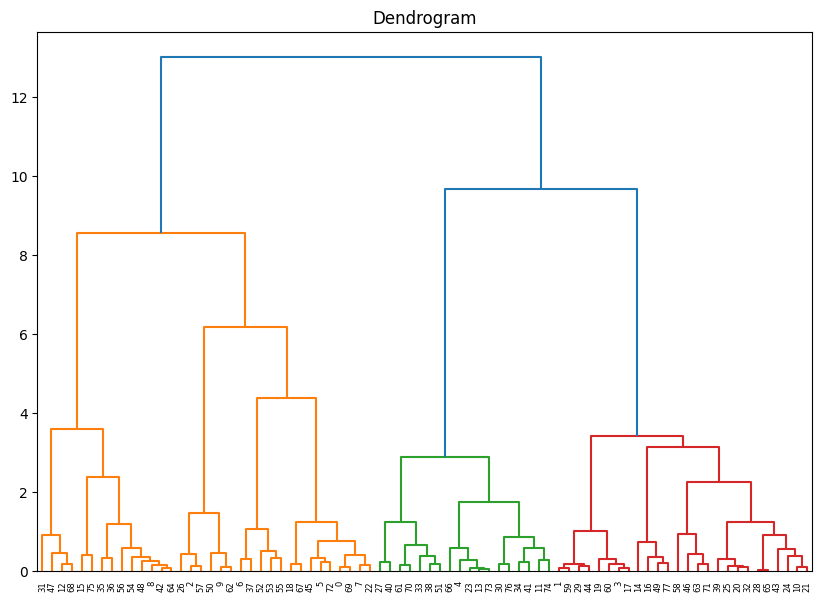

In [ ]:
linked = linkage(scaled_features, method='ward')

plt.figure(figsize=(10,7))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

hc = AgglomerativeClustering(n_clusters=4)
hc_clusters = hc.fit_predict(scaled_features)

customer_data['Hierarchical_Cluster'] = hc_clusters

## ***11) DBSCAN Clustering***

DBSCAN groups data based on density and can identify noise points.

In [ ]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_clusters = dbscan.fit_predict(scaled_features)

customer_data['DBSCAN_Cluster'] = dbscan_clusters

# Handle noise
if len(set(dbscan_clusters)) > 1 and -1 in dbscan_clusters:
    mask = dbscan_clusters != -1
    dbscan_score = silhouette_score(scaled_features[mask], dbscan_clusters[mask])
else:
    dbscan_score = -1

## ***12) Gaussian Mixture Model (GMM)***

GMM uses probability distributions to assign data points to clusters.

In [ ]:
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_clusters = gmm.fit_predict(scaled_features)

customer_data['GMM_Cluster'] = gmm_clusters

gmm_score = silhouette_score(scaled_features, gmm_clusters)

## ***13) Model Evaluation using Silhouette Score***

Silhouette Score is used to evaluate the quality of clustering.

In [ ]:
kmeans_score = silhouette_score(scaled_features, clusters)
hc_score = silhouette_score(scaled_features, hc_clusters)

comparison_df = pd.DataFrame({
    'Model': ['K-Means', 'Hierarchical', 'DBSCAN', 'GMM'],
    'Clusters': [
        len(set(clusters)),
        len(set(hc_clusters)),
        len(set(dbscan_clusters)) - (1 if -1 in dbscan_clusters else 0),
        len(set(gmm_clusters))
    ],
    'Silhouette Score': [
        kmeans_score,
        hc_score,
        dbscan_score,
        gmm_score
    ]
})

comparison_df

,Model,Clusters,Silhouette Score
0,K-Means,4,0.365625
1,Hierarchical,4,0.450219
2,DBSCAN,5,0.490789
3,GMM,4,0.185363


# ***14) BAR GRAPH(Best Model)***

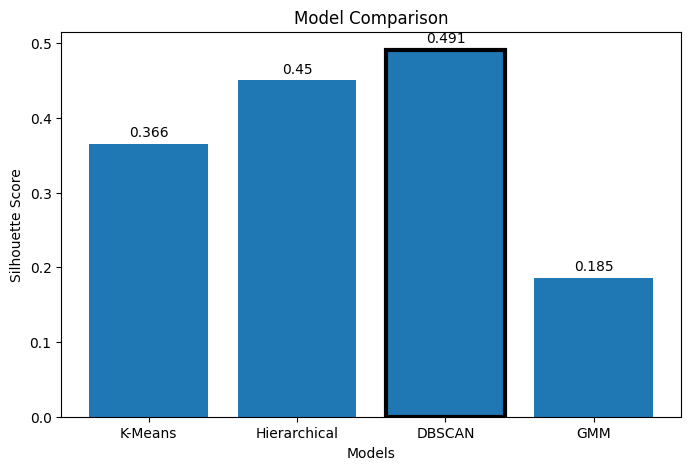


BEST MODEL: DBSCAN
BEST SCORE: 0.4907891568534767


In [ ]:
plt.figure(figsize=(8,5))
bars = plt.bar(comparison_df['Model'], comparison_df['Silhouette Score'])

plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Silhouette Score")

best_index = comparison_df['Silhouette Score'].idxmax()
bars[best_index].set_edgecolor('black')
bars[best_index].set_linewidth(3)

for i, v in enumerate(comparison_df['Silhouette Score']):
    plt.text(i, v + 0.01, round(v, 3), ha='center')

plt.show()

best_model = comparison_df.loc[best_index]
print("\nBEST MODEL:", best_model['Model'])
print("BEST SCORE:", best_model['Silhouette Score'])

## ***15) Cluster Visualization***

Clusters are visualized using PCA-reduced data.

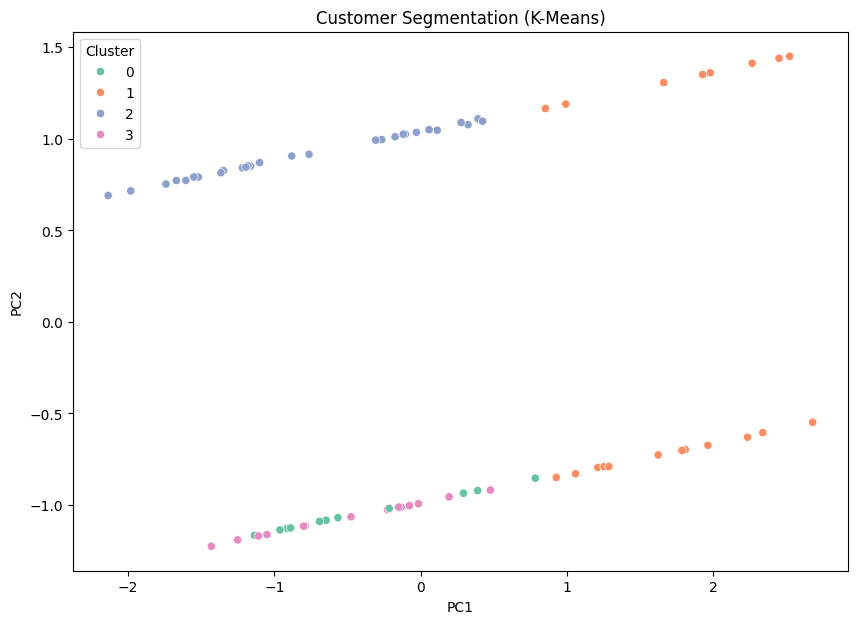

In [ ]:
plt.figure(figsize=(10,7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='Set2')
plt.title("Customer Segmentation (K-Means)")
plt.show()

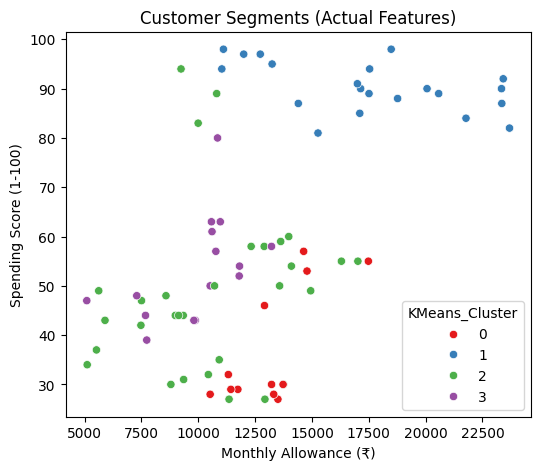

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x='Monthly Allowance (₹)',
    y='Spending Score (1-100)',
    hue='KMeans_Cluster',
    data=customer_data,
    palette='Set1'
)
plt.title("Customer Segments (Actual Features)")
plt.show()

## ***16) Cluster Analysis***

The average values of each cluster are analyzed to understand customer behavior.

In [ ]:
cluster_summary = customer_data.groupby('KMeans_Cluster')[features.columns].mean()
print("\nCLUSTER SUMMARY:\n")
print(cluster_summary.round(2))


CLUSTER SUMMARY:

                  Age  Monthly Allowance (₹)  Spending Score (1-100)
KMeans_Cluster                                                      
0               20.60               10793.83                   43.47
1               18.54               19244.46                   89.15
2               20.42               13909.17                   88.33
3               18.57               11139.30                   46.91


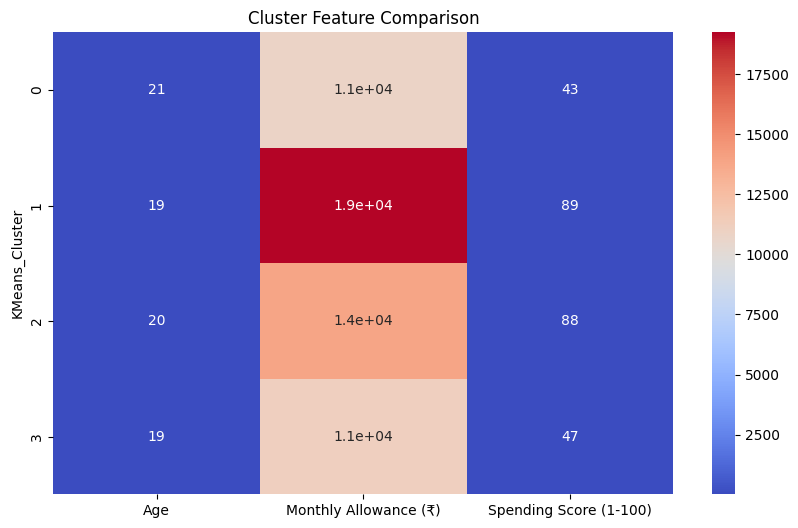

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(cluster_summary, annot=True, cmap='coolwarm')
plt.title("Cluster Feature Comparison")
plt.show()

## ***17) Saving Results***

The segmented dataset is saved for future use.

In [ ]:
customer_data.to_csv("segmented_customers.csv", index=False)

## ***18) Conclusion***

- K-Means clustering provided clear and well-separated customer groups.
- Hierarchical clustering helped visualize the relationships between clusters.
- DBSCAN identified noise and achieved the highest silhouette score, indicating better-defined clusters.
- GMM provided flexible clustering but slightly lower performance.

Overall, DBSCAN was the most effective model for this dataset, achieving the highest silhouette score.

This segmentation can help businesses target customers more effectively based on spending behavior and income.